# Exploratory Data Analysis: Social Media Time Wasters Dataset

This notebook performs comprehensive exploratory data analysis on the Time Wasters on Social Media dataset to understand patterns in social media usage and their relationship with addiction levels.

## 1. Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:

df = pd.read_csv('data/Time_Wasters_on_Social_Media.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (1000, 31)
Number of samples: 1000
Number of features: 31


## 2. Data Overview

In [5]:
# Display first few rows
df.head(10)

,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,Total Time Spent,Number of Sessions,Video ID,Video Category,Video Length,Engagement,Importance Score,Time Spent On Video,Number of Videos Watched,Scroll Rate,Frequency,ProductivityLoss,Satisfaction,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType
0,1,56,Male,Pakistan,82812,True,True,Engineer,Rural,Instagram,80,17,4229,Pranks,24,7867,5,26,22,87,Night,3,7,Procrastination,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
1,2,46,Female,Mexico,27999,False,True,Artist,Urban,Instagram,228,14,2131,Pranks,19,5944,6,25,31,46,Afternoon,5,5,Habit,Computer,Android,5:00 PM,7,3,At school,Wi-Fi
2,3,32,Female,United States,42436,False,True,Engineer,Rural,Facebook,30,6,4367,Vlogs,19,8674,3,9,7,88,Evening,6,4,Entertainment,Tablet,Android,2:00 PM,8,2,At home,Mobile Data
3,4,60,Male,Barzil,62963,True,False,Waiting staff,Rural,YouTube,101,19,1507,Vlogs,4,2477,2,6,41,93,Night,3,7,Habit,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
4,5,25,Male,Pakistan,22096,False,True,Manager,Urban,TikTok,136,6,2159,Gaming,19,3093,7,13,21,4,Morning,8,2,Boredom,Smartphone,iOS,8:00 AM,10,0,At home,Mobile Data
5,6,38,Male,Vietnam,45279,False,False,driver,Urban,Instagram,89,18,2917,Jokes/Memes,9,8534,5,27,16,38,Night,3,7,Entertainment,Computer,Android,9:00 PM,5,5,At home,Wi-Fi
6,7,56,Male,India,46201,False,False,Students,Rural,TikTok,247,5,3230,Vlogs,16,7207,9,22,20,63,Morning,8,2,Habit,Smartphone,Android,8:00 AM,10,0,At school,Wi-Fi
7,8,36,Male,Barzil,39715,False,False,Engineer,Rural,Instagram,191,6,9859,Entertainment,27,9654,3,28,43,29,Night,3,7,Entertainment,Tablet,Android,9:00 PM,5,5,At home,Mobile Data
8,9,40,Male,United States,49309,False,False,Waiting staff,Rural,Instagram,34,2,6266,Vlogs,4,9394,8,20,44,19,Night,3,7,Entertainment,Computer,Android,9:00 PM,5,5,At home,Mobile Data
9,10,28,Other,United States,35078,False,False,Students,Rural,YouTube,165,8,4137,ASMR,6,9813,6,4,47,91,Evening,6,4,Boredom,Smartphone,iOS,2:00 PM,8,2,At home,Mobile Data


In [6]:
# Data types and basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   UserID                    1000 non-null   int64
 1   Age                       1000 non-null   int64
 2   Gender                    1000 non-null   str  
 3   Location                  1000 non-null   str  
 4   Income                    1000 non-null   int64
 5   Debt                      1000 non-null   bool 
 6   Owns Property             1000 non-null   bool 
 7   Profession                1000 non-null   str  
 8   Demographics              1000 non-null   str  
 9   Platform                  1000 non-null   str  
 10  Total Time Spent          1000 non-null   int64
 11  Number of Sessions        1000 non-null   int64
 12  Video ID                  1000 non-null   int64
 13  Video Category            1000 non-null   str  
 14  Video Length              1000 non-null   int64
 15 

In [7]:
# Column names
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. UserID
 2. Age
 3. Gender
 4. Location
 5. Income
 6. Debt
 7. Owns Property
 8. Profession
 9. Demographics
10. Platform
11. Total Time Spent
12. Number of Sessions
13. Video ID
14. Video Category
15. Video Length
16. Engagement
17. Importance Score
18. Time Spent On Video
19. Number of Videos Watched
20. Scroll Rate
21. Frequency
22. ProductivityLoss
23. Satisfaction
24. Watch Reason
25. DeviceType
26. OS
27. Watch Time
28. Self Control
29. Addiction Level
30. CurrentActivity
31. ConnectionType


In [8]:

df.describe()

,UserID,Age,Income,Total Time Spent,Number of Sessions,Video ID,Video Length,Engagement,Importance Score,Time Spent On Video,Number of Videos Watched,Scroll Rate,ProductivityLoss,Satisfaction,Self Control,Addiction Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.986000,59524.213000,151.406000,10.013000,4891.738000,15.214000,4997.159000,5.129000,14.973000,25.248000,49.774000,5.136000,4.864000,7.094000,2.906000
std,288.819436,13.497852,23736.212925,83.952637,5.380314,2853.144258,8.224953,2910.053701,2.582834,8.200092,14.029159,29.197798,2.122265,2.122265,2.058495,2.058495
min,1.000000,18.000000,20138.000000,10.000000,1.000000,11.000000,1.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000
25%,250.750000,29.000000,38675.250000,78.000000,6.000000,2542.000000,8.000000,2415.750000,3.000000,8.000000,14.000000,23.000000,3.000000,4.000000,5.000000,2.000000
50%,500.500000,42.000000,58805.000000,152.000000,10.000000,4720.500000,15.000000,5016.000000,5.000000,15.000000,25.000000,50.000000,5.000000,5.000000,7.000000,3.000000
75%,750.250000,52.000000,79792.250000,223.000000,15.000000,7346.000000,22.000000,7540.250000,7.000000,22.000000,37.000000,74.000000,6.000000,7.000000,8.000000,5.000000
max,1000.000000,64.000000,99676.000000,298.000000,19.000000,9997.000000,29.000000,9982.000000,9.000000,29.000000,49.000000,99.000000,9.000000,9.000000,10.000000,7.000000


## 3. Missing Values Analysis

In [9]:

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values,'Percentage': missing_percent}).sort_values(by='Missing Values',ascending=False)
print(missing_df[missing_df['Missing Values'] > 0])


Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [11]:
duplicates = df.duplicated().sum()
print(f"number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")

number of duplicate rows: 0
Percentage of duplicates: 0.00%


## 4. Target Variable Analysis: Addiction Level

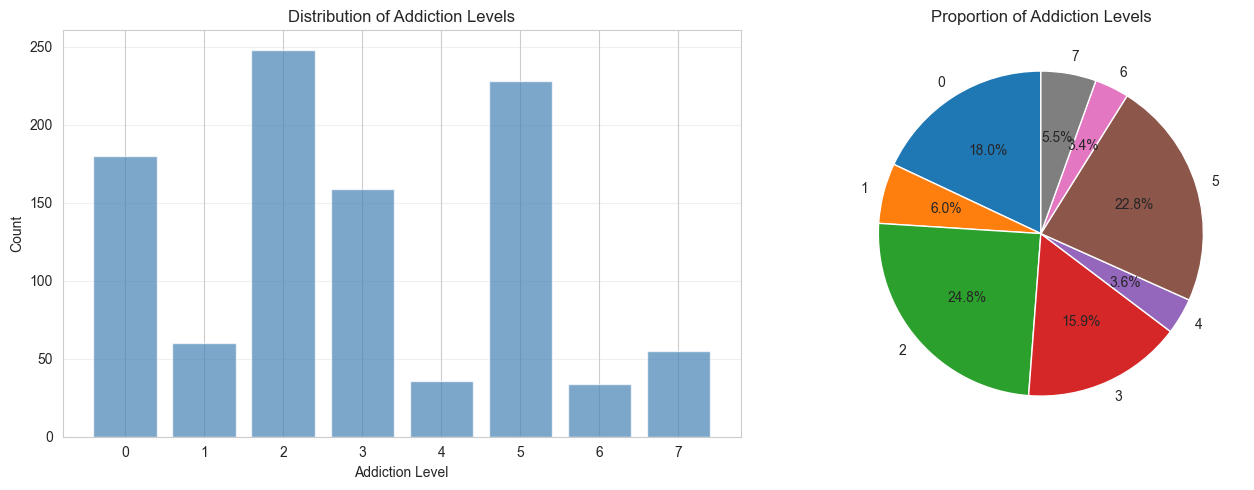


Addiction Level Statistics:
Addiction Level
0    180
1     60
2    248
3    159
4     36
5    228
6     34
7     55
Name: count, dtype: int64

Mean Addiction Level: 2.91
Median Addiction Level: 3.00
Mode Addiction Level: 2


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


addiction_counts = df['Addiction Level'].value_counts().sort_index()
axes[0].bar(addiction_counts.index, addiction_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Addiction Level')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Addiction Levels')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(addiction_counts.values, labels=addiction_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion of Addiction Levels')

plt.tight_layout()
plt.show()

print("\nAddiction Level Statistics:")
print(addiction_counts)
print(f"\nMean Addiction Level: {df['Addiction Level'].mean():.2f}")
print(f"Median Addiction Level: {df['Addiction Level'].median():.2f}")
print(f"Mode Addiction Level: {df['Addiction Level'].mode()[0]}")

## 5. Related Target Variables Analysis

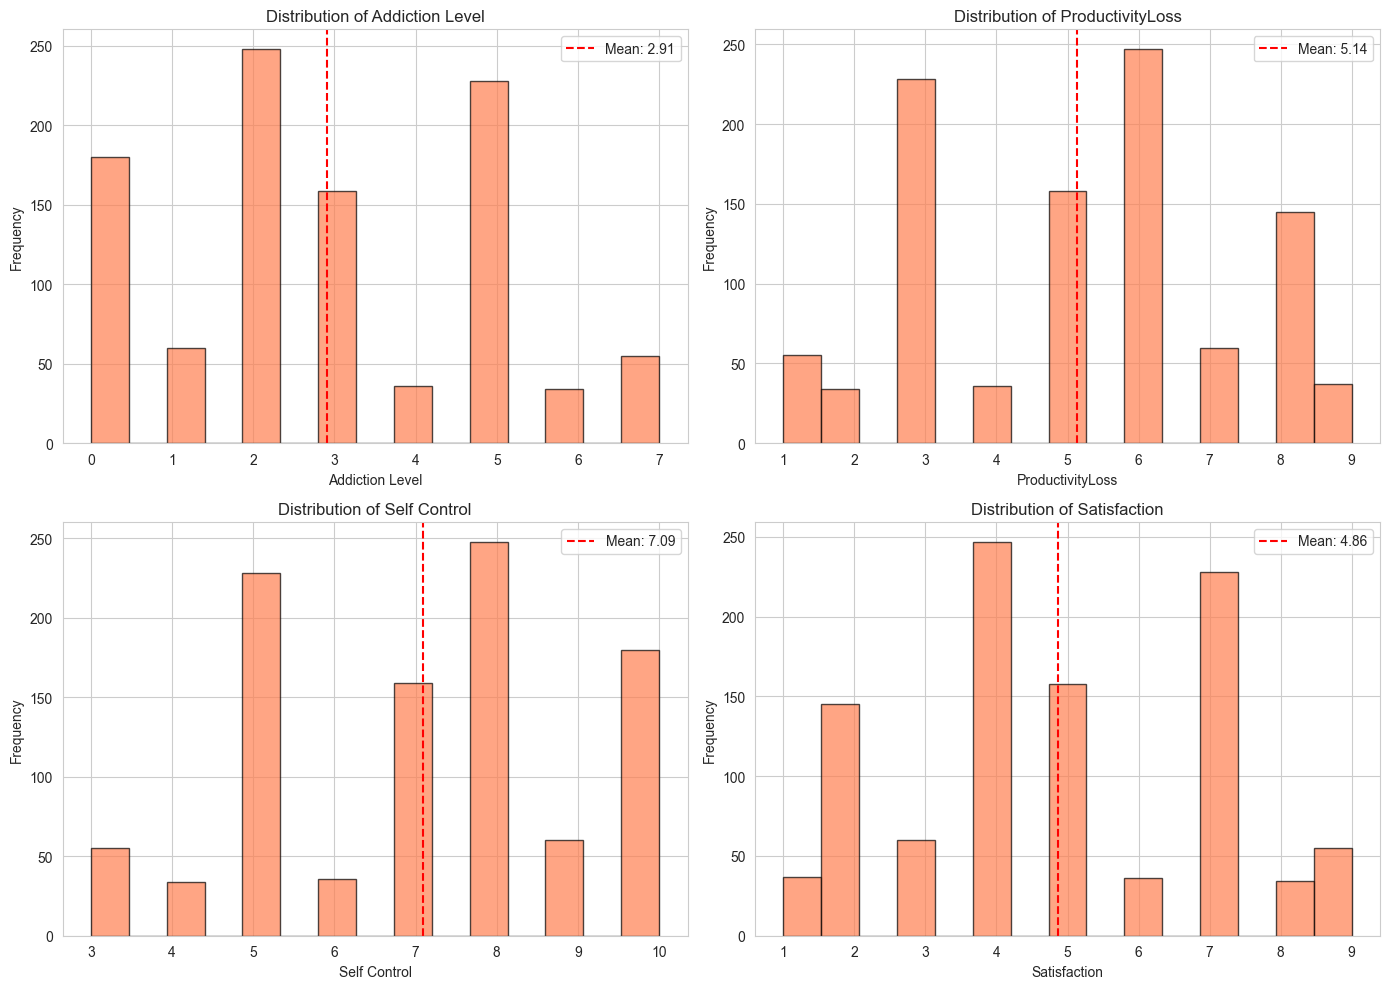

In [13]:

target_vars = ['Addiction Level', 'ProductivityLoss','Self Control', 'Satisfaction']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(target_vars):
    axes[i].hist(df[var], bins=15, color='coral', alpha=0.7, edgecolor='black')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {var}')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', label=f'Mean: {df[var].mean():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

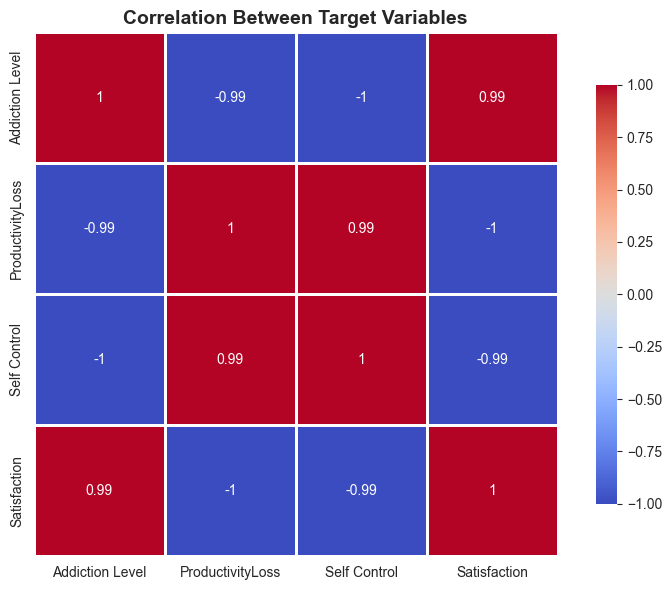


Correlation Matrix:
                  Addiction Level  ProductivityLoss  Self Control  \
Addiction Level          1.000000         -0.994939     -1.000000   
ProductivityLoss        -0.994939          1.000000      0.994939   
Self Control            -1.000000          0.994939      1.000000   
Satisfaction             0.994939         -1.000000     -0.994939   

                  Satisfaction  
Addiction Level       0.994939  
ProductivityLoss     -1.000000  
Self Control         -0.994939  
Satisfaction          1.000000  


In [14]:

target_corr = df[target_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Target Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(target_corr)

## 6. Demographic Features Analysis

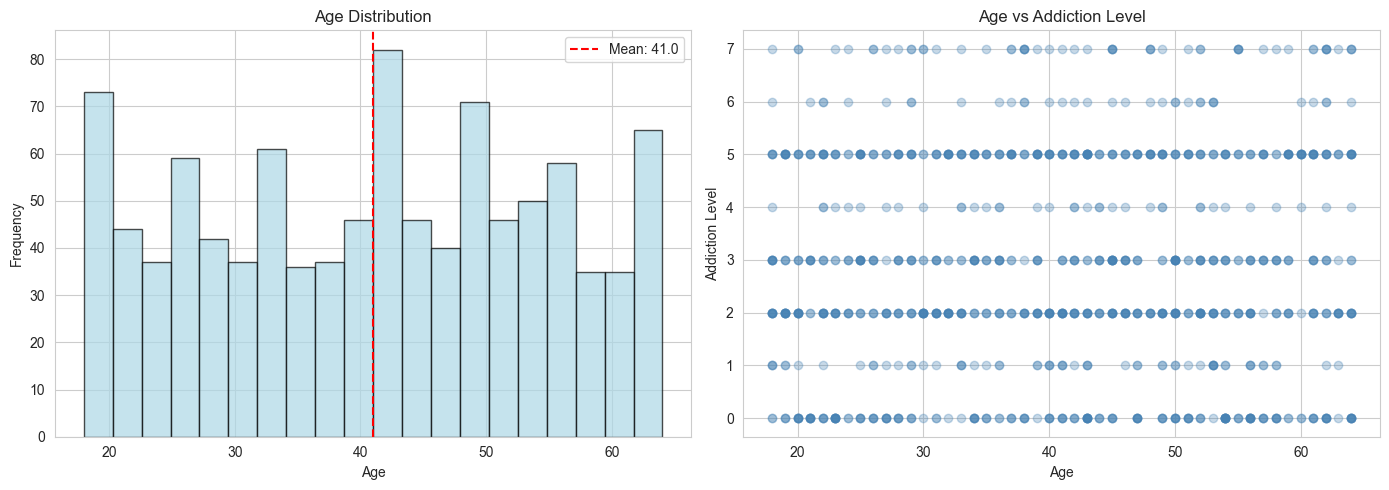

Age range: 18 to 64
Mean age: 40.99
Correlation between Age and Addiction Level: 0.033


In [15]:
fig,axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].legend()
axes[1].scatter(df['Age'], df['Addiction Level'], alpha=0.3, color='steelblue')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Addiction Level')
axes[1].set_title('Age vs Addiction Level')

plt.tight_layout()
plt.show()

print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")
print(f"Mean age: {df['Age'].mean():.2f}")
print(f"Correlation between Age and Addiction Level: {df['Age'].corr(df['Addiction Level']):.3f}")

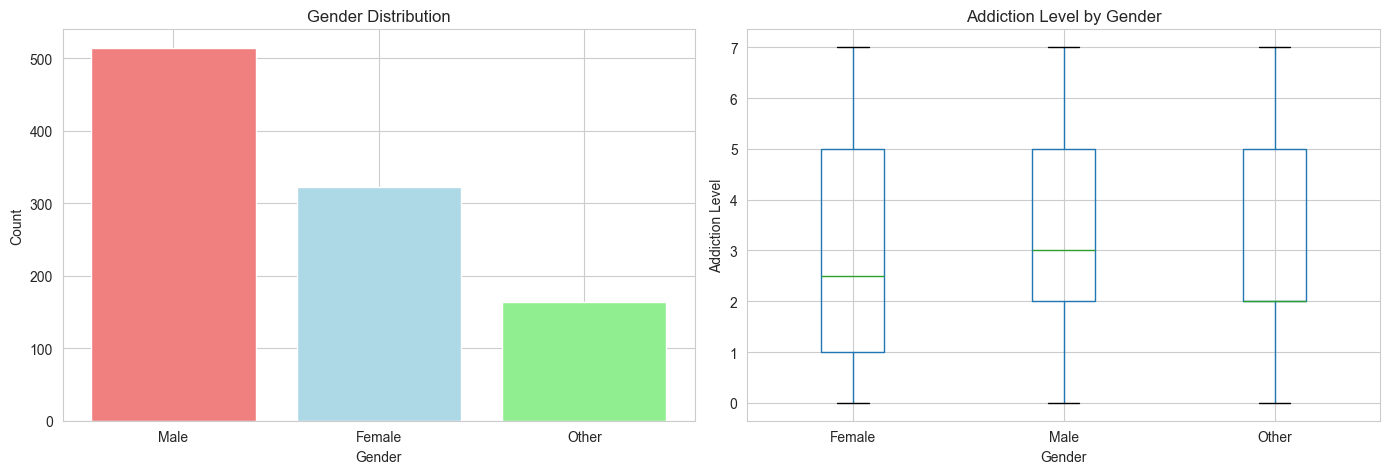


Gender Distribution:
Gender
Male      514
Female    322
Other     164
Name: count, dtype: int64

Mean Addiction Level by Gender:
Gender
Male      2.964981
Female    2.906832
Other     2.719512
Name: Addiction Level, dtype: float64


In [16]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['lightcoral', 'lightblue', 'lightgreen'])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_title('Gender Distribution')

# Gender vs Addiction Level
df.boxplot(column='Addiction Level', by='Gender', ax=axes[1])
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Addiction Level')
axes[1].set_title('Addiction Level by Gender')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nGender Distribution:")
print(gender_counts)
print("\nMean Addiction Level by Gender:")
print(df.groupby('Gender')['Addiction Level'].mean().sort_values(ascending=False))

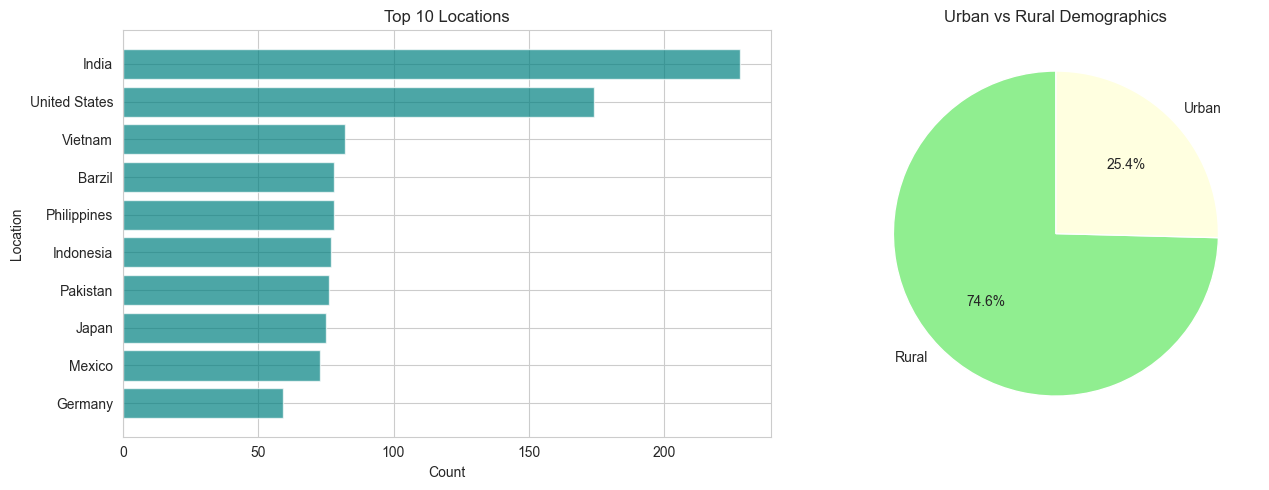

In [17]:
fig,axes = plt.subplots(1, 2, figsize=(14, 5))
top_locations = df['Location'].value_counts().head(10)
axes[0].barh(top_locations.index, top_locations.values, color='teal', alpha=0.7)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Location')
axes[0].set_title('Top 10 Locations')
axes[0].invert_yaxis()
demo_counts = df['Demographics'].value_counts()
axes[1].pie(demo_counts.values, labels=demo_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['lightgreen', 'lightyellow'])
axes[1].set_title('Urban vs Rural Demographics')

plt.tight_layout()
plt.show()

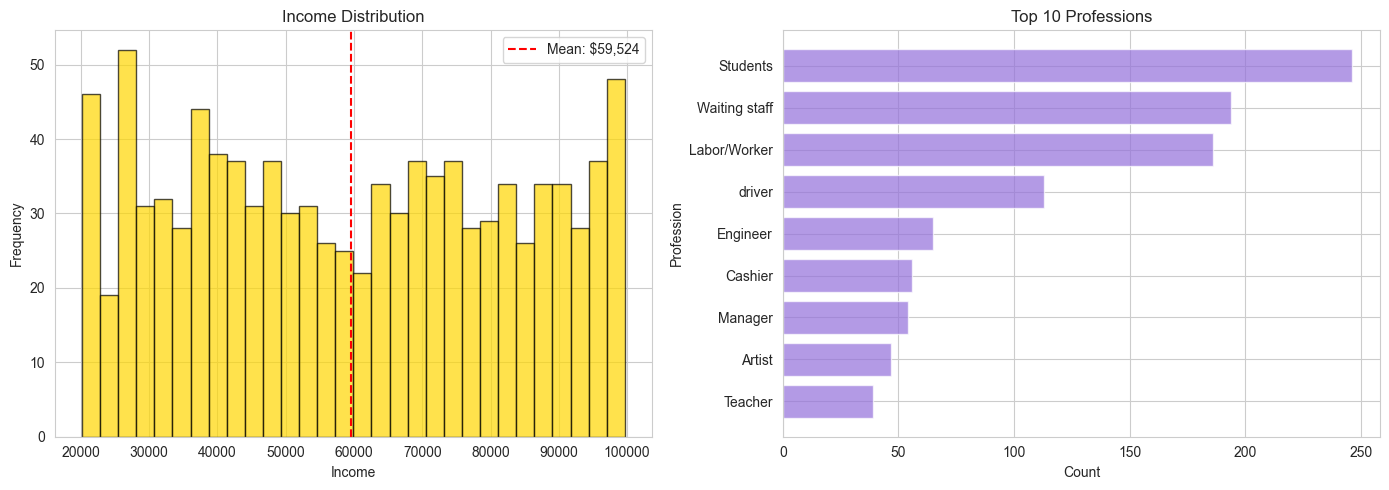

Income range: $20,138 to $99,676
mean income: $59,524.21
Correlation between Income and Addiction Level: -0.039


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Income'], bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Income Distribution')
axes[0].axvline(df['Income'].mean(), color='red',linestyle='--', label=f'Mean: ${df["Income"].mean():,.0f}')
axes[0].legend()
top_professions = df['Profession'].value_counts().head(10)
axes[1].barh(top_professions.index, top_professions.values, color='mediumpurple', alpha=0.7)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Profession')
axes[1].set_title('Top 10 Professions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Income range: ${df['Income'].min():,} to ${df['Income'].max():,}")
print(f"mean income: ${df['Income'].mean():,.2f}")
print(f"Correlation between Income and Addiction Level: {df['Income'].corr(df['Addiction Level']):.3f}")

## 7. Platform and Usage Analysis

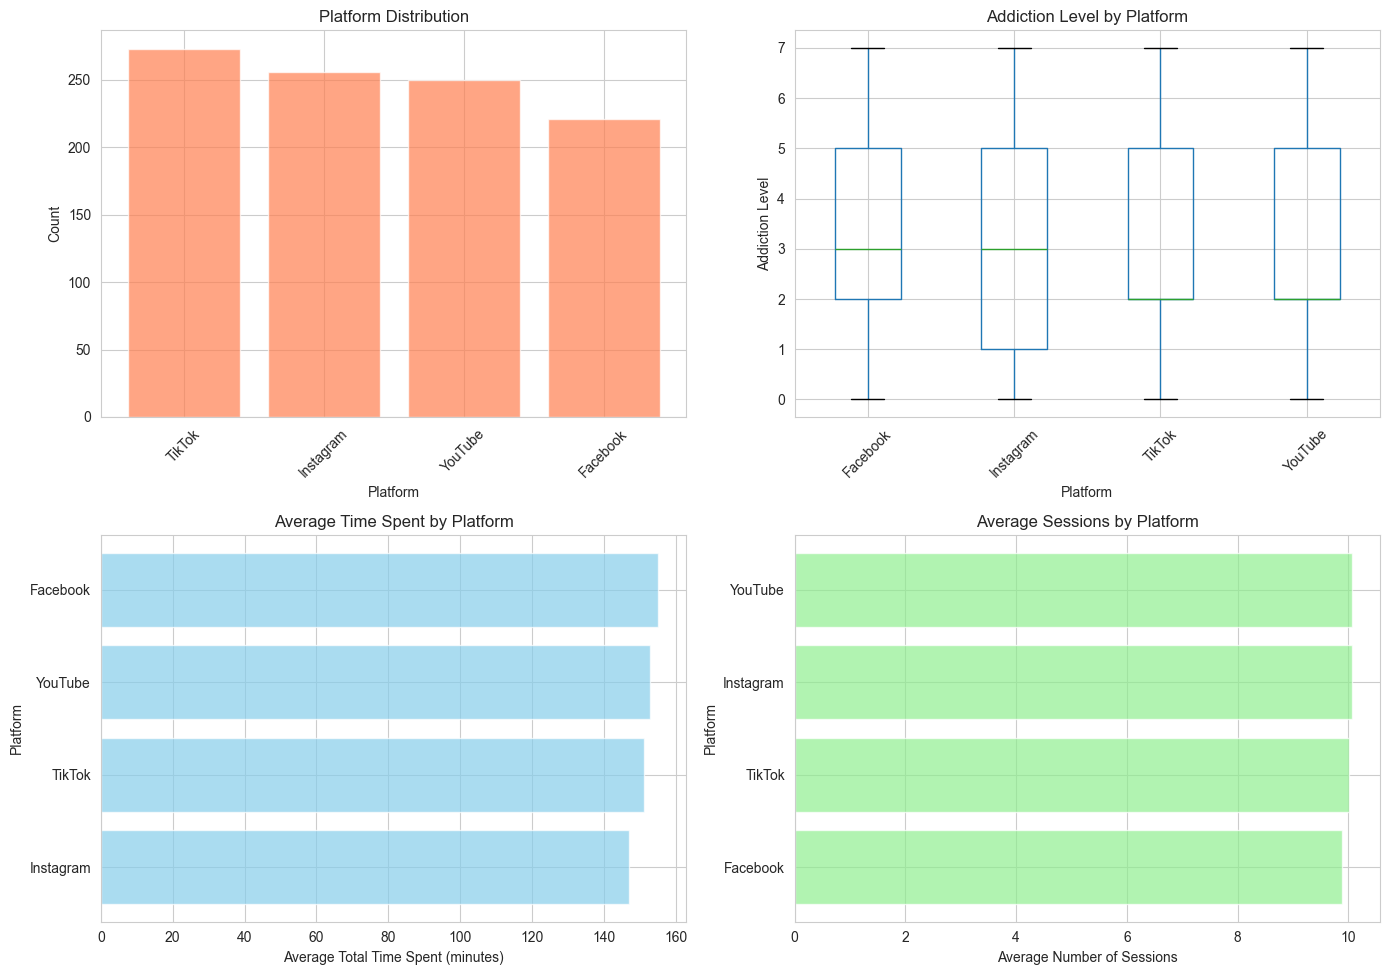


Mean Addiction Level by Platform:
Platform
Facebook     2.977376
Instagram    2.960938
TikTok       2.912088
YouTube      2.780000
Name: Addiction Level, dtype: float64


In [ ]:
fig,axes = plt.subplots(2, 2, figsize=(14, 10))


platform_counts = df['Platform'].value_counts()
axes[0, 0].bar(platform_counts.index, platform_counts.values, color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Platform')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Platform Distribution')
axes[0, 0].tick_params(axis='x', rotation=45)
df.boxplot(column='Addiction Level', by='Platform', ax=axes[0, 1])
axes[0, 1].set_xlabel('Platform')
axes[0, 1].set_ylabel('Addiction Level')
axes[0, 1].set_title('Addiction Level by Platform')
axes[0, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

platform_time = df.groupby('Platform')['Total Time Spent'].mean().sort_values(ascending=False)
axes[1, 0].barh(platform_time.index, platform_time.values, color='skyblue', alpha=0.7)
axes[1, 0].set_xlabel('Average Total Time Spent (minutes)')
axes[1, 0].set_ylabel('Platform')
axes[1, 0].set_title('Average Time Spent by Platform')
axes[1, 0].invert_yaxis()

platform_sessions = df.groupby('Platform')['Number of Sessions'].mean().sort_values(ascending=False)
axes[1, 1].barh(platform_sessions.index, platform_sessions.values, color='lightgreen', alpha=0.7)
axes[1, 1].set_xlabel('Average Number of Sessions')
axes[1, 1].set_ylabel('Platform')
axes[1, 1].set_title('Average Sessions by Platform')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nMean Addiction Level by Platform:")
print(df.groupby('Platform')['Addiction Level'].mean().sort_values(ascending=False))

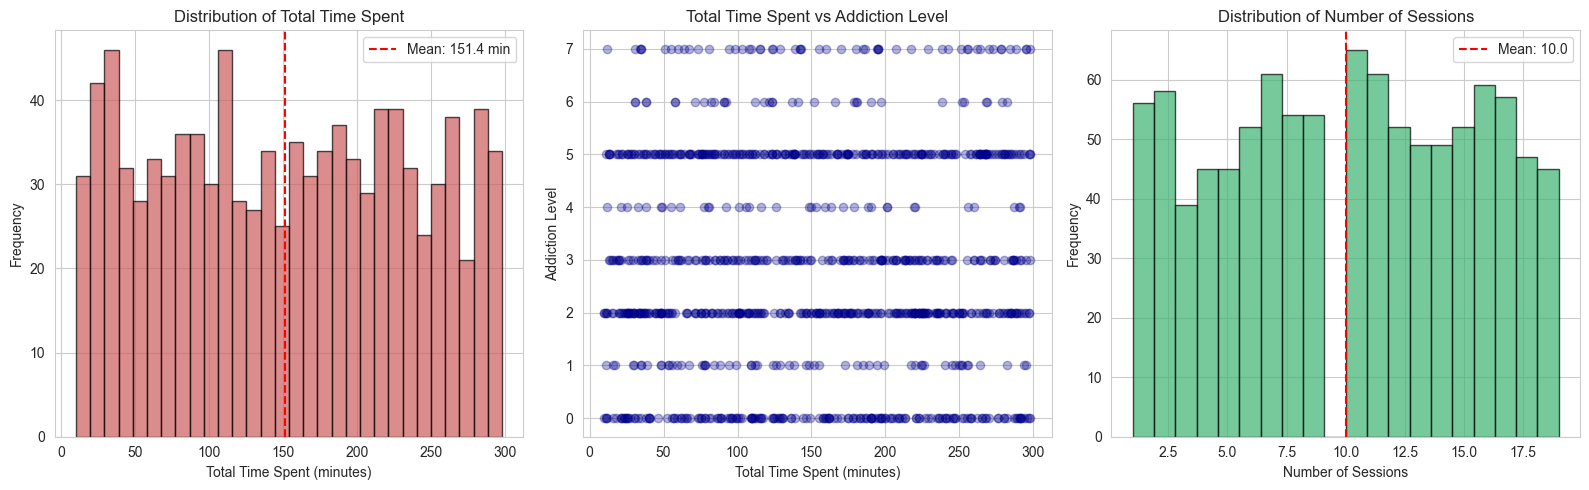


Total Time Spent - Mean: 151.41, Median: 152.00
Number of Sessions - Mean: 10.01, Median: 10.00

Correlations with Addiction Level:
  Total Time Spent: 0.016
  Number of Sessions: -0.081


In [20]:
# Time spent analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total Time Spent distribution
axes[0].hist(df['Total Time Spent'], bins=30, color='indianred', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Time Spent (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Time Spent')
axes[0].axvline(df['Total Time Spent'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["Total Time Spent"].mean():.1f} min')
axes[0].legend()

# Total Time Spent vs Addiction Level
axes[1].scatter(df['Total Time Spent'], df['Addiction Level'], alpha=0.3, color='darkblue')
axes[1].set_xlabel('Total Time Spent (minutes)')
axes[1].set_ylabel('Addiction Level')
axes[1].set_title('Total Time Spent vs Addiction Level')

# Number of Sessions distribution
axes[2].hist(df['Number of Sessions'], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Number of Sessions')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Number of Sessions')
axes[2].axvline(df['Number of Sessions'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Number of Sessions"].mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nTotal Time Spent - Mean: {df['Total Time Spent'].mean():.2f}, Median: {df['Total Time Spent'].median():.2f}")
print(f"Number of Sessions - Mean: {df['Number of Sessions'].mean():.2f}, Median: {df['Number of Sessions'].median():.2f}")
print(f"\nCorrelations with Addiction Level:")
print(f"  Total Time Spent: {df['Total Time Spent'].corr(df['Addiction Level']):.3f}")
print(f"  Number of Sessions: {df['Number of Sessions'].corr(df['Addiction Level']):.3f}")

## 8. Video Engagement Analysis

In [ ]:
# Video category analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Video Category distribution
top_categories = df['Video Category'].value_counts().head(10)
axes[0, 0].barh(top_categories.index, top_categories.values, color='orchid', alpha=0.7)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Video Category')
axes[0, 0].set_title('Top 10 Video Categories')
axes[0, 0].invert_yaxis()

# Addiction Level by Video Category (top 5)
top_5_categories = df['Video Category'].value_counts().head(5).index
df[df['Video Category'].isin(top_5_categories)].boxplot(column='Addiction Level', by='Video Category', ax=axes[0, 1])
axes[0, 1].set_xlabel('Video Category')
axes[0, 1].set_ylabel('Addiction Level')
axes[0, 1].set_title('Addiction Level by Top 5 Video Categories')
axes[0, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

# Video Length distribution
axes[1, 0].hist(df['Video Length'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Video Length (minutes)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Video Length Distribution')
axes[1, 0].axvline(df['Video Length'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["Video Length"].mean():.1f} min')
axes[1, 0].legend()

# Engagement distribution
axes[1, 1].hist(df['Engagement'], bins=30, color='lightseagreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Engagement Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Engagement Score Distribution')
axes[1, 1].axvline(df['Engagement'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["Engagement"].mean():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Video watching behavior
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Number of Videos Watched
axes[0].hist(df['Number of Videos Watched'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Videos Watched')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Videos Watched')

# Scroll Rate
axes[1].hist(df['Scroll Rate'], bins=30, color='dodgerblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Scroll Rate')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Scroll Rate Distribution')

# Importance Score
axes[2].hist(df['Importance Score'], bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Importance Score')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Importance Score Distribution')

plt.tight_layout()
plt.show()

print("\nCorrelations with Addiction Level:")
print(f"  Engagement: {df['Engagement'].corr(df['Addiction Level']):.3f}")
print(f"  Number of Videos Watched: {df['Number of Videos Watched'].corr(df['Addiction Level']):.3f}")
print(f"  Scroll Rate: {df['Scroll Rate'].corr(df['Addiction Level']):.3f}")
print(f"  Importance Score: {df['Importance Score'].corr(df['Addiction Level']):.3f}")

## 9. Behavioral Patterns Analysis

In [ ]:
# Watch timing patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frequency (time of day)
freq_counts = df['Frequency'].value_counts()
axes[0, 0].bar(freq_counts.index, freq_counts.values, color='darkorange', alpha=0.7)
axes[0, 0].set_xlabel('Time of Day')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Usage Frequency by Time of Day')
axes[0, 0].tick_params(axis='x', rotation=45)

# Addiction Level by Frequency
df.boxplot(column='Addiction Level', by='Frequency', ax=axes[0, 1])
axes[0, 1].set_xlabel('Time of Day')
axes[0, 1].set_ylabel('Addiction Level')
axes[0, 1].set_title('Addiction Level by Time of Day')
axes[0, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

# Watch Reason
reason_counts = df['Watch Reason'].value_counts()
axes[1, 0].bar(reason_counts.index, reason_counts.values, color='seagreen', alpha=0.7)
axes[1, 0].set_xlabel('Watch Reason')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Watch Reasons')
axes[1, 0].tick_params(axis='x', rotation=45)

# Addiction Level by Watch Reason
df.boxplot(column='Addiction Level', by='Watch Reason', ax=axes[1, 1])
axes[1, 1].set_xlabel('Watch Reason')
axes[1, 1].set_ylabel('Addiction Level')
axes[1, 1].set_title('Addiction Level by Watch Reason')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nMean Addiction Level by Time of Day:")
print(df.groupby('Frequency')['Addiction Level'].mean().sort_values(ascending=False))
print("\nMean Addiction Level by Watch Reason:")
print(df.groupby('Watch Reason')['Addiction Level'].mean().sort_values(ascending=False))

In [ ]:
# Current Activity analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Current Activity distribution
activity_counts = df['CurrentActivity'].value_counts()
axes[0].barh(activity_counts.index, activity_counts.values, color='teal', alpha=0.7)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Current Activity')
axes[0].set_title('Distribution of Current Activity')
axes[0].invert_yaxis()

# Addiction Level by Current Activity
df.boxplot(column='Addiction Level', by='CurrentActivity', ax=axes[1])
axes[1].set_xlabel('Current Activity')
axes[1].set_ylabel('Addiction Level')
axes[1].set_title('Addiction Level by Current Activity')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nMean Addiction Level by Current Activity:")
print(df.groupby('CurrentActivity')['Addiction Level'].mean().sort_values(ascending=False))

## 10. Device and Connection Analysis

In [ ]:
# Device and OS analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Device Type
device_counts = df['DeviceType'].value_counts()
axes[0, 0].bar(device_counts.index, device_counts.values, color='mediumpurple', alpha=0.7)
axes[0, 0].set_xlabel('Device Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Device Type Distribution')

# Addiction Level by Device Type
df.boxplot(column='Addiction Level', by='DeviceType', ax=axes[0, 1])
axes[0, 1].set_xlabel('Device Type')
axes[0, 1].set_ylabel('Addiction Level')
axes[0, 1].set_title('Addiction Level by Device Type')
plt.suptitle('')

# Operating System
os_counts = df['OS'].value_counts()
axes[1, 0].bar(os_counts.index, os_counts.values, color='coral', alpha=0.7)
axes[1, 0].set_xlabel('Operating System')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Operating System Distribution')

# Connection Type
conn_counts = df['ConnectionType'].value_counts()
axes[1, 1].pie(conn_counts.values, labels=conn_counts.index, autopct='%1.1f%%', startangle=90,
               colors=['lightblue', 'lightgreen'])
axes[1, 1].set_title('Connection Type Distribution')

plt.tight_layout()
plt.show()

print("\nMean Addiction Level by Device Type:")
print(df.groupby('DeviceType')['Addiction Level'].mean().sort_values(ascending=False))
print("\nMean Addiction Level by OS:")
print(df.groupby('OS')['Addiction Level'].mean().sort_values(ascending=False))

## 11. Correlation Analysis

In [ ]:
# Select numerical features for correlation analysis
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)

In [ ]:
# Correlation matrix for all numerical features
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Top correlations with Addiction Level
addiction_corr = df[numerical_features].corr()['Addiction Level'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in addiction_corr.values]
plt.barh(range(len(addiction_corr)), addiction_corr.values, color=colors, alpha=0.6)
plt.yticks(range(len(addiction_corr)), addiction_corr.index)
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlations with Addiction Level', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop Positive Correlations with Addiction Level:")
print(addiction_corr.head(10))
print("\nTop Negative Correlations with Addiction Level:")
print(addiction_corr.tail(10))

## 12. Key Insights and Summary

In [ ]:
# Summary statistics for key features by Addiction Level
print("=" * 80)
print("KEY INSIGHTS SUMMARY")
print("=" * 80)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total samples: {len(df):,}")
print(f"   - Total features: {len(df.columns)}")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Duplicate rows: {df.duplicated().sum()}")

print("\n2. TARGET VARIABLE (Addiction Level):")
print(f"   - Range: {df['Addiction Level'].min()} to {df['Addiction Level'].max()}")
print(f"   - Mean: {df['Addiction Level'].mean():.2f}")
print(f"   - Median: {df['Addiction Level'].median():.2f}")
print(f"   - Most common: {df['Addiction Level'].mode()[0]}")
print(f"   - Distribution:")
for level in sorted(df['Addiction Level'].unique()):
    count = (df['Addiction Level'] == level).sum()
    pct = (count / len(df)) * 100
    print(f"     Level {level}: {count:4d} ({pct:5.2f}%)")

print("\n3. STRONGEST CORRELATIONS WITH ADDICTION LEVEL:")
top_5_pos = addiction_corr[addiction_corr.index != 'Addiction Level'].head(5)
for feature, corr in top_5_pos.items():
    print(f"   - {feature}: {corr:.3f}")

print("\n4. PLATFORM INSIGHTS:")
platform_stats = df.groupby('Platform').agg({
    'Addiction Level': 'mean',
    'Total Time Spent': 'mean',
    'UserID': 'count'
}).round(2)
platform_stats.columns = ['Avg Addiction', 'Avg Time (min)', 'Users']
print(platform_stats.sort_values('Avg Addiction', ascending=False))

print("\n5. WATCH REASON INSIGHTS:")
reason_stats = df.groupby('Watch Reason')['Addiction Level'].mean().sort_values(ascending=False)
for reason, avg in reason_stats.items():
    print(f"   - {reason}: {avg:.2f}")

print("\n6. TIME OF DAY INSIGHTS:")
time_stats = df.groupby('Frequency')['Addiction Level'].mean().sort_values(ascending=False)
for time, avg in time_stats.items():
    print(f"   - {time}: {avg:.2f}")

print("\n7. KEY NUMERICAL FEATURES:")
key_features = ['Total Time Spent', 'Number of Sessions', 'Engagement', 
                'Self Control', 'ProductivityLoss', 'Satisfaction']
for feature in key_features:
    if feature in df.columns:
        corr = df[feature].corr(df['Addiction Level'])
        mean = df[feature].mean()
        print(f"   - {feature}: Mean={mean:.2f}, Correlation={corr:.3f}")

print("\n" + "=" * 80)

## 13. Additional Insights and Recommendations

In [ ]:
# Create addiction level groups for comparison
df['Addiction_Group'] = pd.cut(df['Addiction Level'], bins=[-0.1, 2, 3, 5], 
                                labels=['Low (0-2)', 'Medium (3)', 'High (4-5)'])

print("BEHAVIORAL PATTERNS BY ADDICTION GROUP:")
print("\nAverage Time Spent by Addiction Group:")
print(df.groupby('Addiction_Group')['Total Time Spent'].mean().round(2))

print("\nAverage Sessions by Addiction Group:")
print(df.groupby('Addiction_Group')['Number of Sessions'].mean().round(2))

print("\nAverage Videos Watched by Addiction Group:")
print(df.groupby('Addiction_Group')['Number of Videos Watched'].mean().round(2))

print("\nAverage Self Control by Addiction Group:")
print(df.groupby('Addiction_Group')['Self Control'].mean().round(2))

print("\nMost Common Platform by Addiction Group:")
for group in df['Addiction_Group'].unique():
    if pd.notna(group):
        most_common = df[df['Addiction_Group'] == group]['Platform'].mode()[0]
        print(f"  {group}: {most_common}")

In [ ]:
# Visualization of key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Self Control vs Addiction Level
axes[0, 0].scatter(df['Self Control'], df['Addiction Level'], alpha=0.3, color='navy')
axes[0, 0].set_xlabel('Self Control')
axes[0, 0].set_ylabel('Addiction Level')
axes[0, 0].set_title(f'Self Control vs Addiction Level\n(r={df["Self Control"].corr(df["Addiction Level"]):.3f})')

# ProductivityLoss vs Addiction Level
axes[0, 1].scatter(df['ProductivityLoss'], df['Addiction Level'], alpha=0.3, color='darkred')
axes[0, 1].set_xlabel('Productivity Loss')
axes[0, 1].set_ylabel('Addiction Level')
axes[0, 1].set_title(f'Productivity Loss vs Addiction Level\n(r={df["ProductivityLoss"].corr(df["Addiction Level"]):.3f})')

# Satisfaction vs Addiction Level
axes[1, 0].scatter(df['Satisfaction'], df['Addiction Level'], alpha=0.3, color='darkgreen')
axes[1, 0].set_xlabel('Satisfaction')
axes[1, 0].set_ylabel('Addiction Level')
axes[1, 0].set_title(f'Satisfaction vs Addiction Level\n(r={df["Satisfaction"].corr(df["Addiction Level"]):.3f})')

# Time Spent on Video vs Addiction Level
axes[1, 1].scatter(df['Time Spent On Video'], df['Addiction Level'], alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Time Spent On Video')
axes[1, 1].set_ylabel('Addiction Level')
axes[1, 1].set_title(f'Time Spent On Video vs Addiction Level\n(r={df["Time Spent On Video"].corr(df["Addiction Level"]):.3f})')

plt.tight_layout()
plt.show()

## 14. Report-Ready Figures

The following cells generate cleaner figures tailored to the final report and save them to `assets/report_figures/`.

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split

report_fig_dir = Path('assets/report_figures')
report_fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')

def save_report_figure(fig, filename):
    path = report_fig_dir / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved figure to {path}")


In [ ]:
# Figure 1: split sizes and class balance for both prediction targets
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.15,
    random_state=42,
    stratify=df['Addiction Level']
)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=(0.15 / 0.85),
    random_state=42,
    stratify=df.loc[train_idx, 'Addiction Level']
)

split_counts = pd.Series({
    'Train': len(train_idx),
    'Validation': len(val_idx),
    'Test': len(test_idx)
})
addiction_counts = df['Addiction Level'].value_counts().sort_index()
productivity_counts = df['ProductivityLoss'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.barplot(x=split_counts.index, y=split_counts.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Train / Validation / Test Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Number of Samples')
for i, value in enumerate(split_counts.values):
    axes[0].text(i, value + 10, str(value), ha='center', va='bottom', fontsize=11)

sns.barplot(x=addiction_counts.index, y=addiction_counts.values, color='steelblue', ax=axes[1])
axes[1].set_title('Addiction Level Distribution')
axes[1].set_xlabel('Addiction Level')
axes[1].set_ylabel('Count')
for i, value in enumerate(addiction_counts.values):
    axes[1].text(i, value + 4, str(value), ha='center', va='bottom', fontsize=10)

sns.barplot(x=productivity_counts.index, y=productivity_counts.values, color='darkorange', ax=axes[2])
axes[2].set_title('Productivity Loss Distribution')
axes[2].set_xlabel('Productivity Loss')
axes[2].set_ylabel('Count')
for i, value in enumerate(productivity_counts.values):
    axes[2].text(i, value + 4, str(value), ha='center', va='bottom', fontsize=10)

save_report_figure(fig, 'sample_split_and_label_balance.png')


In [ ]:
# Figure 2: correlations among the main behavioral and outcome variables discussed in the report
key_corr_features = [
    'Addiction Level',
    'ProductivityLoss',
    'Self Control',
    'Satisfaction',
    'Total Time Spent',
    'Number of Sessions',
    'Time Spent On Video',
    'Scroll Rate',
    'Engagement'
]
corr_matrix = df[key_corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Key Behavioral and Outcome Correlations')

save_report_figure(fig, 'key_relationships_heatmap.png')


In [ ]:
# Figure 3: demographic coverage and subgroup patterns for the fairness/generalizability discussion
gender_order = ['Male', 'Female', 'Other']
demo_order = ['Urban', 'Rural']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

gender_counts = df['Gender'].value_counts().reindex(gender_order)
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Gender Distribution')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
for i, value in enumerate(gender_counts.values):
    axes[0, 0].text(i, value + 8, str(int(value)), ha='center', va='bottom', fontsize=10)

demo_counts = df['Demographics'].value_counts().reindex(demo_order)
sns.barplot(x=demo_counts.index, y=demo_counts.values, palette='Pastel1', ax=axes[0, 1])
axes[0, 1].set_title('Urban vs Rural Distribution')
axes[0, 1].set_xlabel('Demographics')
axes[0, 1].set_ylabel('Count')
for i, value in enumerate(demo_counts.values):
    axes[0, 1].text(i, value + 12, str(int(value)), ha='center', va='bottom', fontsize=10)

sns.boxplot(data=df, x='Gender', y='Addiction Level', order=gender_order, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Addiction Level by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Addiction Level')

sns.regplot(
    data=df,
    x='Age',
    y='Addiction Level',
    lowess=True,
    scatter_kws={'alpha': 0.2, 's': 25, 'color': 'steelblue'},
    line_kws={'color': 'black', 'linewidth': 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title(f"Age vs Addiction Level (r={df['Age'].corr(df['Addiction Level']):.02f})")
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Addiction Level')

save_report_figure(fig, 'demographic_patterns.png')


In [ ]:
# Figure 4: platform and behavioral patterns that can be cited directly in the report discussion
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

platform_means = df.groupby('Platform')['Addiction Level'].mean().sort_values(ascending=False)
sns.barplot(x=platform_means.index, y=platform_means.values, palette='rocket', ax=axes[0, 0])
axes[0, 0].set_title('Average Addiction Level by Platform')
axes[0, 0].set_xlabel('Platform')
axes[0, 0].set_ylabel('Average Addiction Level')
axes[0, 0].tick_params(axis='x', rotation=20)

reason_means = df.groupby('Watch Reason')['Addiction Level'].mean().sort_values(ascending=False)
sns.barplot(x=reason_means.index, y=reason_means.values, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Average Addiction Level by Watch Reason')
axes[0, 1].set_xlabel('Watch Reason')
axes[0, 1].set_ylabel('Average Addiction Level')
axes[0, 1].tick_params(axis='x', rotation=20)

freq_means = df.groupby('Frequency')['Addiction Level'].mean().sort_values(ascending=False)
sns.barplot(x=freq_means.index, y=freq_means.values, palette='mako', ax=axes[1, 0])
axes[1, 0].set_title('Average Addiction Level by Time of Day')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Average Addiction Level')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.regplot(
    data=df,
    x='Total Time Spent',
    y='Addiction Level',
    lowess=True,
    scatter_kws={'alpha': 0.2, 's': 25, 'color': 'darkblue'},
    line_kws={'color': 'black', 'linewidth': 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title(
    f"Total Time Spent vs Addiction Level (r={df['Total Time Spent'].corr(df['Addiction Level']):.02f})"
)
axes[1, 1].set_xlabel('Total Time Spent (minutes)')
axes[1, 1].set_ylabel('Addiction Level')

save_report_figure(fig, 'behavioral_patterns.png')


## Conclusions

Based on the exploratory data analysis, we can draw several conclusions:

1. **Target Variable Distribution**: The addiction levels in the dataset show a specific distribution pattern that will be important for model training.

2. **Strong Predictors**: Several features show strong correlations with addiction level, particularly behavioral metrics like self-control, productivity loss, and usage patterns.

3. **Platform Differences**: Different social media platforms show varying average addiction levels, suggesting platform-specific behavior patterns.

4. **Temporal Patterns**: Usage timing (time of day) and watch reasons provide insights into addiction-related behaviors.

5. **Data Quality**: The dataset appears clean with no missing values, making it suitable for machine learning applications.

### Recommendations for Modeling:

- Focus on behavioral features (Self Control, ProductivityLoss, Satisfaction) as they show strong correlations
- Consider platform-specific patterns in feature engineering
- Watch reasons and timing patterns could be valuable categorical features
- The observed class imbalance suggests using macro F\textsubscript{1} and stratified splits during evaluation
- Consider interaction features between usage time and platform type